# Phân tích cổ phiếu FPT end-to-end

Notebook này đọc dữ liệu đặc trưng từ `data_stocks_features.parquet`, phân tích nhanh dữ liệu cổ phiếu FPT, trực quan hóa xu hướng quan trọng và huấn luyện mô hình dự báo giá đóng cửa.

## 1. Thiết lập môi trường và import thư viện

Phần này import các thư viện cần thiết cho Spark, phân tích dữ liệu và trực quan hóa.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, LinearRegressionModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

## 2. Đọc dữ liệu cổ phiếu FPT

Ta đọc dữ liệu đặc trưng đã được tạo sẵn, sau đó chỉ lấy mã FPT để phân tích và huấn luyện.

In [4]:
spark = SparkSession.builder.appName("FPTStockAnalysis").getOrCreate()

source_path = Path("data_stocks_features.parquet")
df = spark.read.parquet(str(source_path))

fpt_df = (
    df.filter(df.ticker == "FPT")
      .select("time", "ticker", "open", "high", "low", "close", "volume", "prev_close", "ma7", "daily_return")
      .orderBy("time")
)

print("Số dòng dữ liệu FPT:", fpt_df.count())
fpt_df.show(5, truncate=False)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 07:29:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Số dòng dữ liệu FPT: 1877
+----------+------+-----+-----+-----+-----+-------+----------+------------------+----------------------+
|time      |ticker|open |high |low  |close|volume |prev_close|ma7               |daily_return          |
+----------+------+-----+-----+-----+-----+-------+----------+------------------+----------------------+
|2018-08-31|FPT   |13.94|14.18|13.93|13.96|1027280|13.94     |13.95             |0.0014347202295553337 |
|2018-09-04|FPT   |13.93|14.12|13.89|13.93|634400 |13.96     |13.943333333333333|-0.0021489971346705682|
|2018-09-05|FPT   |13.91|13.96|13.58|13.67|843460 |13.93     |13.875            |-0.018664752333094028 |
|2018-09-06|FPT   |13.61|13.67|13.37|13.37|1206190|13.67     |13.774000000000001|-0.02194586686174109  |
|2018-09-07|FPT   |13.42|13.58|13.37|13.58|508770 |13.37     |13.741666666666667|0.015706806282722578  |
+----------+------+-----+-----+-----+-----+-------+----------+------------------+----------------------+
only showing top 5 rows


## 3. Tiền xử lý và biến đổi dữ liệu

Chọn bộ đặc trưng đầu vào, làm sạch giá trị thiếu và tách train/test theo mốc thời gian để tránh rò rỉ dữ liệu.

In [5]:
feature_cols = ["prev_close", "ma7", "daily_return"]
model_df = (
    fpt_df
    .na.drop(subset=feature_cols + ["close", "time"])
)

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
prepared_df = assembler.transform(model_df).select("time", "close", "features", *feature_cols)

train_df = prepared_df.filter(prepared_df.time < "2024-01-01")
test_df = prepared_df.filter(prepared_df.time >= "2024-01-01")

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

Train rows: 1335
Test rows: 542


## 4. Phân tích nhanh bằng thống kê mô tả

Tính các chỉ số cơ bản để hiểu phân phối dữ liệu, mức biến động và tương quan giữa các đặc trưng.

In [6]:
stats_pdf = fpt_df.select("open", "high", "low", "close", "volume", "prev_close", "ma7", "daily_return").toPandas()

print(stats_pdf.describe().T)
print("\nMedian:\n", stats_pdf.median(numeric_only=True))
print("\nQuantiles:\n", stats_pdf.quantile([0.25, 0.5, 0.75]))
print("\nCorrelation with close:\n", stats_pdf.corr(numeric_only=True)["close"].sort_values(ascending=False))

               count          mean           std            min           25%  \
open          1877.0  5.515459e+01  3.435240e+01      12.630000  2.092000e+01   
high          1877.0  5.575803e+01  3.469968e+01      13.040000  2.106000e+01   
low           1877.0  5.456490e+01  3.397649e+01      12.630000  2.074000e+01   
close         1877.0  5.514749e+01  3.431425e+01      12.880000  2.092000e+01   
volume        1877.0  3.067609e+06  3.566480e+06  141480.000000  1.128800e+06   
prev_close    1877.0  5.511218e+01  3.432255e+01      12.880000  2.089000e+01   
ma7           1877.0  5.504178e+01  3.431775e+01      13.060000  2.077571e+01   
daily_return  1877.0  1.082842e-03  1.734098e-02      -0.069999 -7.276507e-03   

                       50%           75%           max  
open          4.898000e+01  8.475000e+01  1.315000e+02  
high          4.943000e+01  8.563000e+01  1.331200e+02  
low           4.850000e+01  8.380000e+01  1.309000e+02  
close         4.887000e+01  8.489000e+01  

## 5. Trực quan hóa dữ liệu với Matplotlib/Seaborn

Tập trung vào xu hướng giá, phân phối biến động và mối quan hệ giữa các đặc trưng.

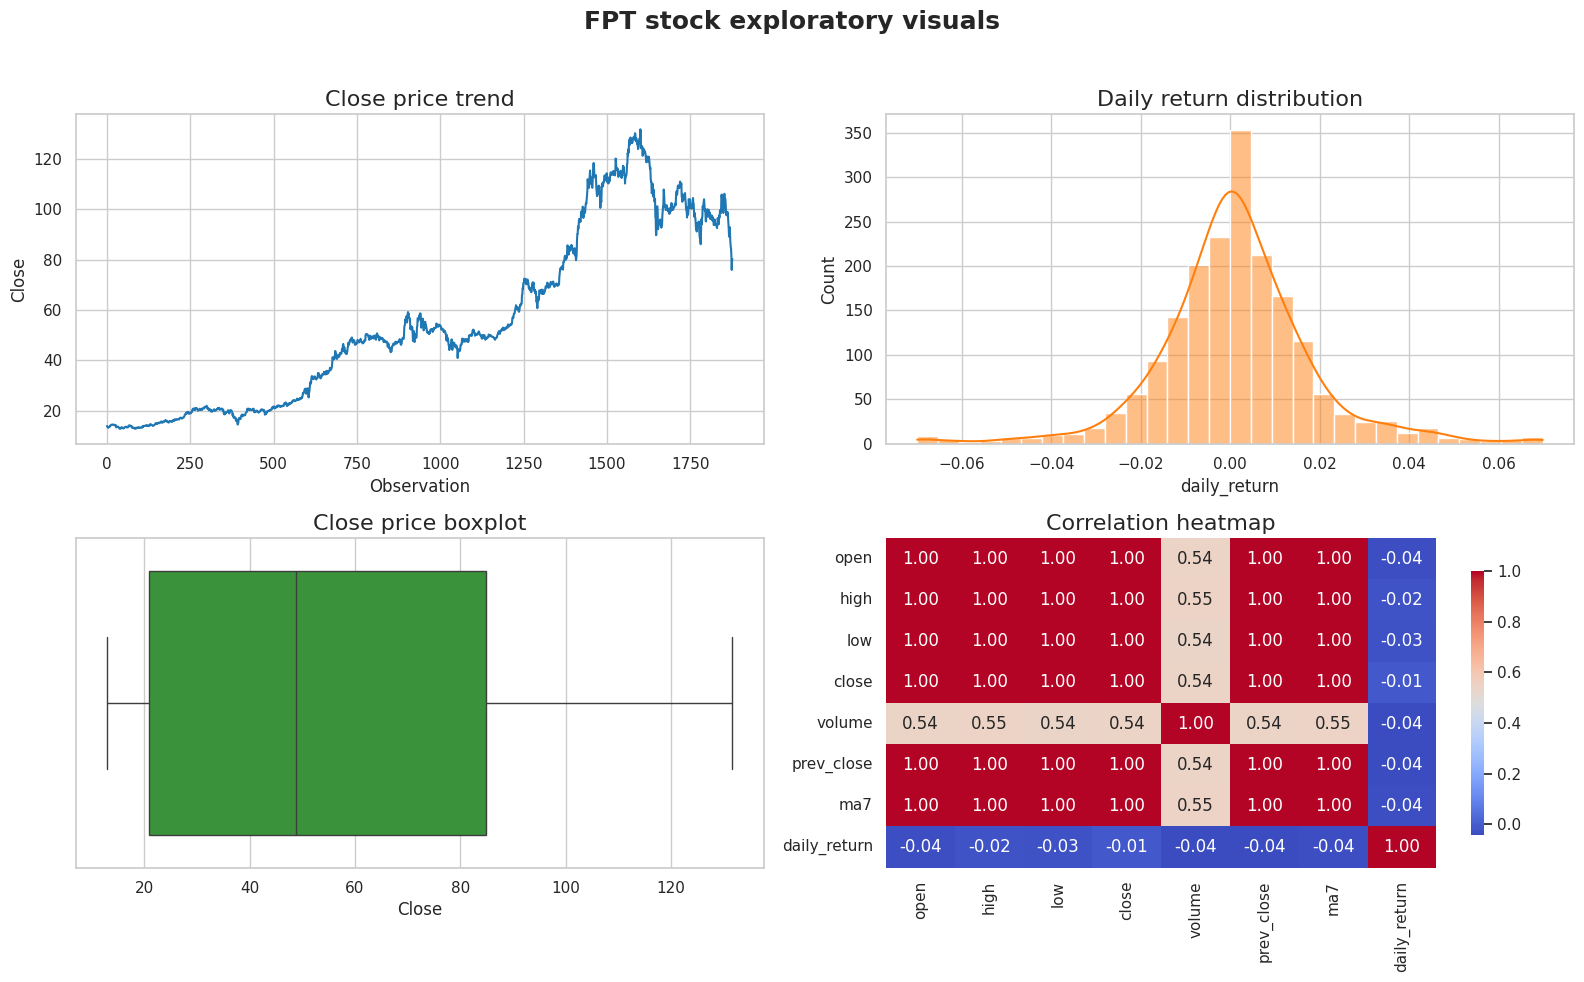

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("FPT stock exploratory visuals", fontsize=18, fontweight="bold")

sns.lineplot(data=stats_pdf.reset_index(), x="index", y="close", ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Close price trend")
axes[0, 0].set_xlabel("Observation")
axes[0, 0].set_ylabel("Close")

sns.histplot(stats_pdf["daily_return"].dropna(), bins=30, kde=True, ax=axes[0, 1], color="#ff7f0e")
axes[0, 1].set_title("Daily return distribution")

sns.boxplot(x=stats_pdf["close"], ax=axes[1, 0], color="#2ca02c")
axes[1, 0].set_title("Close price boxplot")
axes[1, 0].set_xlabel("Close")

corr = stats_pdf.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1], cbar_kws={"shrink": 0.8})
axes[1, 1].set_title("Correlation heatmap")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 6. Xây dựng mô hình baseline bằng Spark ML

Ở notebook này, baseline dùng Linear Regression trên các đặc trưng giá quá khứ để dự báo `close`.

In [8]:
baseline_lr = LinearRegression(featuresCol="features", labelCol="close")
baseline_model = baseline_lr.fit(train_df)

baseline_predictions = baseline_model.transform(test_df)
rmse_evaluator = RegressionEvaluator(labelCol="close", predictionCol="prediction", metricName="rmse")
rmse = rmse_evaluator.evaluate(baseline_predictions)

print(f"Baseline RMSE: {rmse:.4f}")
baseline_predictions.select("time", "close", "prediction").orderBy("time", ascending=False).show(10, truncate=False)

26/04/08 07:30:24 WARN Instrumentation: [82bc6573] regParam is zero, which might cause numerical instability and overfitting.
26/04/08 07:30:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/08 07:30:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Baseline RMSE: 1.1801
+----------+-----+-----------------+
|time      |close|prediction       |
+----------+-----+-----------------+
|2026-03-11|80.2 |79.90829806574013|
|2026-03-10|79.5 |77.80204673802419|
|2026-03-09|75.9 |79.21304703021194|
|2026-03-06|81.6 |83.31615189139823|
|2026-03-05|84.4 |84.92065176293401|
|2026-03-04|85.1 |86.31719738535868|
|2026-03-03|87.0 |88.63383691462509|
|2026-03-02|89.6 |91.65934244837541|
|2026-02-27|92.9 |91.5671304151724 |
|2026-02-26|90.5 |89.82756480220475|
+----------+-----+-----------------+
only showing top 10 rows


## 7. Đánh giá mô hình và tinh chỉnh tham số

Dùng grid search trong Spark để thử vài cấu hình `regParam` và `elasticNetParam`.

In [9]:
param_grid = (
    ParamGridBuilder()
    .addGrid(baseline_lr.regParam, [0.0, 0.01, 0.1])
    .addGrid(baseline_lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

cross_validator = CrossValidator(
    estimator=baseline_lr,
    estimatorParamMaps=param_grid,
    evaluator=rmse_evaluator,
    numFolds=3,
    seed=RANDOM_STATE,
)

cv_model = cross_validator.fit(train_df)
cv_predictions = cv_model.transform(test_df)
cv_rmse = rmse_evaluator.evaluate(cv_predictions)

print(f"Best RMSE after tuning: {cv_rmse:.4f}")
print("Best regParam:", cv_model.bestModel._java_obj.getRegParam())
print("Best elasticNetParam:", cv_model.bestModel._java_obj.getElasticNetParam())

cv_predictions.select("time", "close", "prediction").orderBy("time", ascending=False).show(10, truncate=False)

26/04/08 07:30:30 WARN Instrumentation: [b4b65e60] regParam is zero, which might cause numerical instability and overfitting.
26/04/08 07:30:38 WARN Instrumentation: [d2905319] regParam is zero, which might cause numerical instability and overfitting.
26/04/08 07:30:43 WARN Instrumentation: [8356b8c9] regParam is zero, which might cause numerical instability and overfitting.
26/04/08 07:31:15 WARN Instrumentation: [f6b2b629] regParam is zero, which might cause numerical instability and overfitting.
26/04/08 07:31:20 WARN Instrumentation: [46120afe] regParam is zero, which might cause numerical instability and overfitting.
26/04/08 07:31:24 WARN Instrumentation: [2d289f70] regParam is zero, which might cause numerical instability and overfitting.
26/04/08 07:31:50 WARN Instrumentation: [c6b6c301] regParam is zero, which might cause numerical instability and overfitting.
26/04/08 07:31:54 WARN Instrumentation: [fe55a744] regParam is zero, which might cause numerical instability and overf

Best RMSE after tuning: 1.1801
Best regParam: 0.0
Best elasticNetParam: 0.0
+----------+-----+-----------------+
|time      |close|prediction       |
+----------+-----+-----------------+
|2026-03-11|80.2 |79.90829806574013|
|2026-03-10|79.5 |77.80204673802419|
|2026-03-09|75.9 |79.21304703021194|
|2026-03-06|81.6 |83.31615189139823|
|2026-03-05|84.4 |84.92065176293401|
|2026-03-04|85.1 |86.31719738535868|
|2026-03-03|87.0 |88.63383691462509|
|2026-03-02|89.6 |91.65934244837541|
|2026-02-27|92.9 |91.5671304151724 |
|2026-02-26|90.5 |89.82756480220475|
+----------+-----+-----------------+
only showing top 10 rows


## 8. Lưu mô hình và xuất kết quả dự đoán

Lưu model Spark, xuất file dự đoán ra CSV và lưu biểu đồ để dùng lại sau.

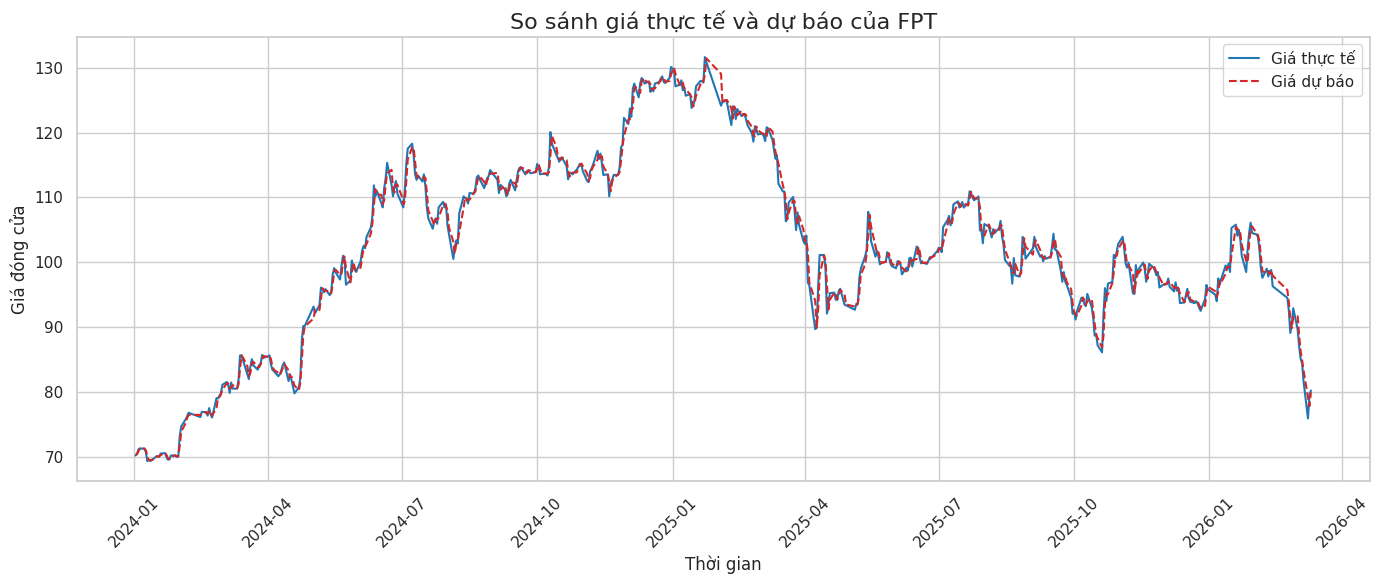

Reloaded model RMSE: 1.180107711599297
         time  close  prediction
0  2024-01-02  70.18   70.283279
1  2024-01-03  70.48   70.370483
2  2024-01-04  71.14   70.849541
3  2024-01-05  71.28   71.230349
4  2024-01-08  71.21   71.262391


In [10]:
output_dir = Path("notebook_outputs")
output_dir.mkdir(exist_ok=True)

final_predictions = cv_model.transform(test_df).select("time", "close", "prediction").orderBy("time")
final_pdf = final_predictions.toPandas()

final_pdf.to_csv(output_dir / "fpt_predictions.csv", index=False)

plt.figure(figsize=(14, 6))
plt.plot(final_pdf["time"], final_pdf["close"], label="Giá thực tế", color="#1f77b4")
plt.plot(final_pdf["time"], final_pdf["prediction"], label="Giá dự báo", color="#d62728", linestyle="--")
plt.title("So sánh giá thực tế và dự báo của FPT")
plt.xlabel("Thời gian")
plt.ylabel("Giá đóng cửa")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
chart_path = output_dir / "fpt_close_vs_prediction.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

cv_model.bestModel.write().overwrite().save(str(output_dir / "fpt_lr_model"))
reloaded_model = LinearRegressionModel.load(str(output_dir / "fpt_lr_model"))
print("Reloaded model RMSE:", rmse_evaluator.evaluate(reloaded_model.transform(test_df)))
print(final_pdf.head())

## 9.Phân rã chuỗi thời gian (Time Series Decomposition)

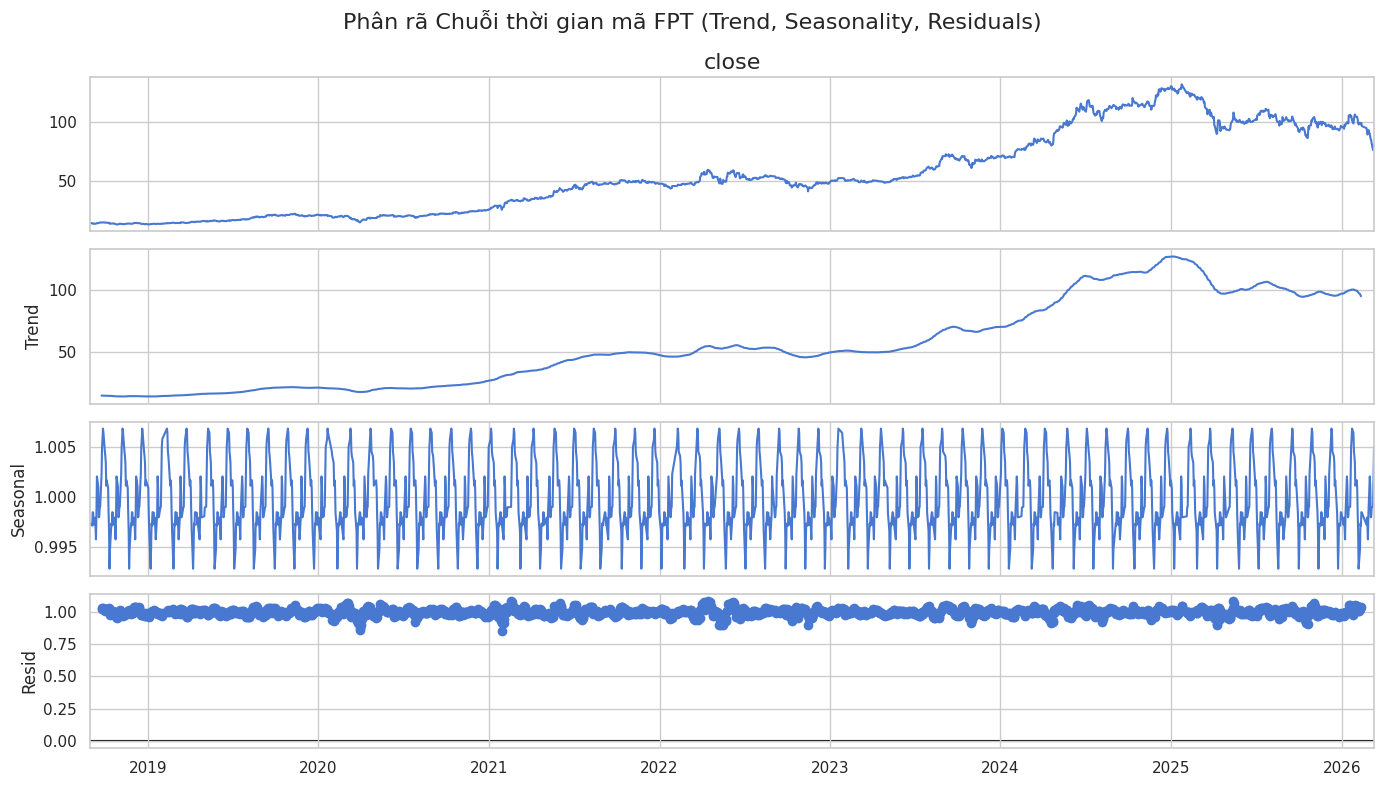

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Lấy dữ liệu của FPT từ Spark chuyển sang Pandas
pdf_fpt = df.filter(df.ticker == "FPT").select("time", "close").orderBy("time").toPandas()

# Đặt time làm index
pdf_fpt['time'] = pd.to_datetime(pdf_fpt['time'])
pdf_fpt.set_index('time', inplace=True)

# 2. Phân rã chuỗi thời gian (Giả sử chu kỳ 30 ngày)
result = seasonal_decompose(pdf_fpt['close'], model='multiplicative', period=30)

# 3. Vẽ biểu đồ phân rã
fig = result.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Phân rã Chuỗi thời gian mã FPT (Trend, Seasonality, Residuals)", fontsize=16)
plt.tight_layout()
plt.show()

## 10.Phân tích nhiều mã


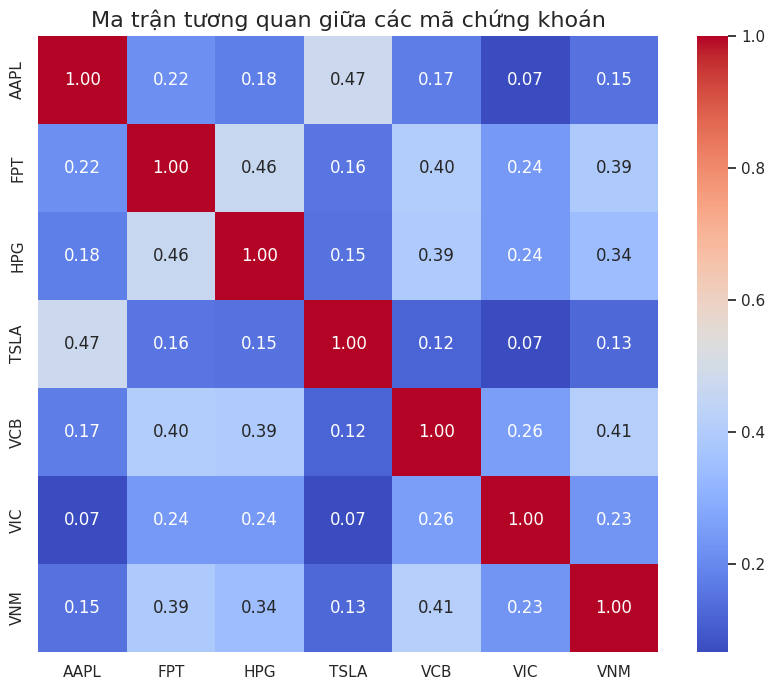

In [17]:
# 0. Khởi tạo Spark Session (nếu chưa có)
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("MarketAnalysis").getOrCreate()

# 1. Đọc lại dữ liệu từ file Parquet mà bạn đã tạo ở các bước trước
# Hãy đảm bảo đường dẫn file 'data_stocks_features.parquet' là chính xác
df = spark.read.parquet("data_stocks_features.parquet")

# 2. Bây giờ mới chạy lệnh Pivot (đoạn code bị lỗi của bạn)
import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = df.groupBy("time").pivot("ticker").mean("close").orderBy("time")

# 3. Chuyển sang Pandas để tính tương quan
pdf_pivot = pivot_df.toPandas()
pdf_pivot.set_index('time', inplace=True)

# Tính tỷ suất sinh lời để ma trận tương quan chính xác hơn
returns_df = pdf_pivot.pct_change().dropna()

# 4. Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan giữa các mã chứng khoán")
plt.show()